# **Customer Orders & Sales Dataset (2024)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')

In [ ]:
#Load Dataset
df = pd.read_csv('orders.csv')

df['order_date'] = pd.to_datetime(df['order_date'])

df.head()

,order_id,customer_id,order_date,category,region,revenue,quantity
0,1001,C0103,2024-01-01 00:00:00,Sports,East,215,1
1,1002,C0436,2024-01-01 01:00:00,Home,South,749,3
2,1003,C0349,2024-01-01 02:00:00,Fashion,South,391,4
3,1004,C0271,2024-01-01 03:00:00,Sports,South,531,3
4,1005,C0107,2024-01-01 04:00:00,Fashion,North,68,4


In [ ]:
#KPI Analysis
#KPI 1: Total Revenue
#KPI 2: Total Orders
#KPI 3: Total Customers
#KPI 4: Average Order Value
#KPI 5: Revenue Per Customer
total_revenue = df['revenue'].sum()

total_orders = len(df)

total_customers = df['customer_id'].nunique()

aov = total_revenue / total_orders

revenue_per_customer = total_revenue / total_customers

print("===== KPI SUMMARY =====")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Average Order Value: ${aov:.2f}")
print(f"Revenue Per Customer: ${revenue_per_customer:.2f}")

===== KPI SUMMARY =====
Total Revenue: $2,642,762.00
Total Orders: 5000
Total Customers: 500
Average Order Value: $528.55
Revenue Per Customer: $5285.52


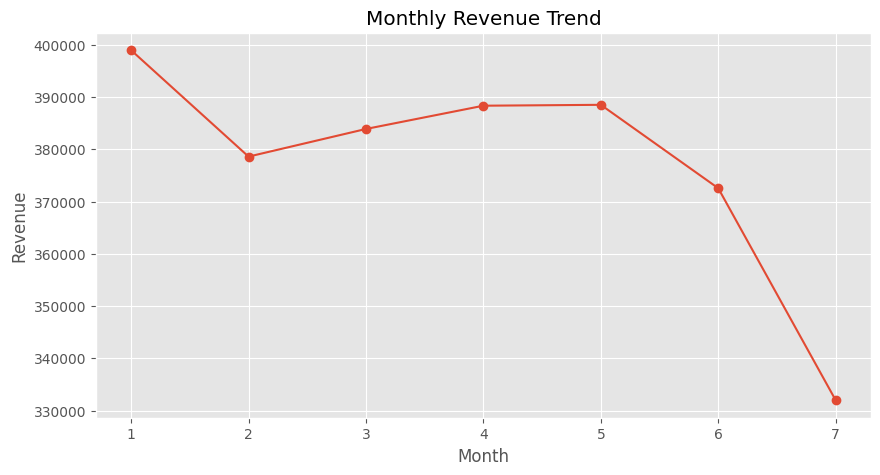

In [ ]:
#Monthly Revenue Trend
monthly_revenue = (
    df.groupby(df['order_date'].dt.month)['revenue']
      .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

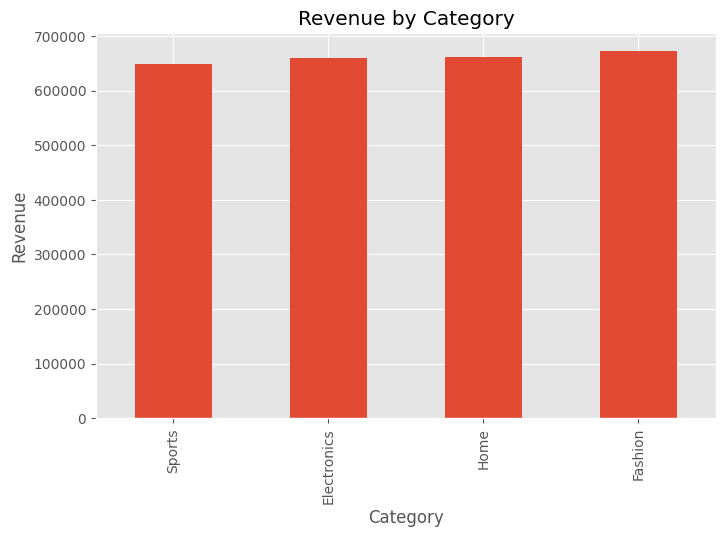

In [ ]:
#Revenue by Category
category_sales = (
    df.groupby('category')['revenue']
      .sum()
      .sort_values()
)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

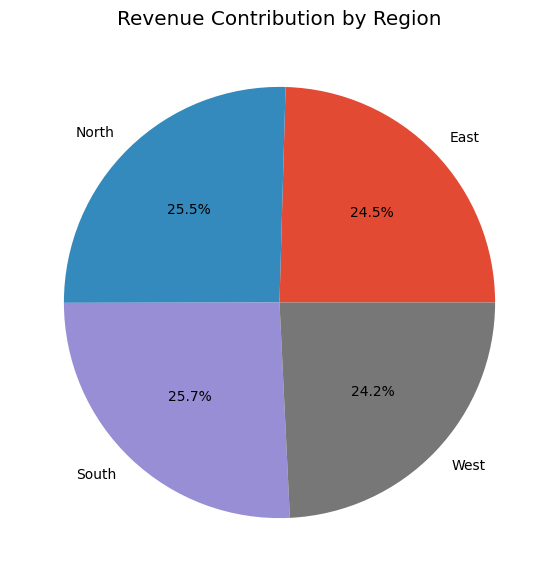

In [ ]:
#Revenue by Region
region_sales = (
    df.groupby('region')['revenue']
      .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Region")

plt.show()

**Deep-Dive Analysis: Customer Segmentation**

In [ ]:
#Build Customer Metrics
customer_metrics = df.groupby('customer_id').agg({
    'revenue':'sum',
    'quantity':'sum'
})

customer_metrics.columns = [
    'TotalRevenue',
    'TotalQuantity'
]

customer_metrics.head()

,TotalRevenue,TotalQuantity
customer_id,,
C0001,7945,35
C0002,4486,18
C0003,4907,21
C0004,4768,28
C0005,7397,42


In [ ]:
#K-Means Clustering
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    customer_metrics
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_metrics['Segment'] = (
    kmeans.fit_predict(scaled_data)
)

customer_metrics.head()

,TotalRevenue,TotalQuantity,Segment
customer_id,,,
C0001,7945,35,0
C0002,4486,18,2
C0003,4907,21,1
C0004,4768,28,1
C0005,7397,42,0


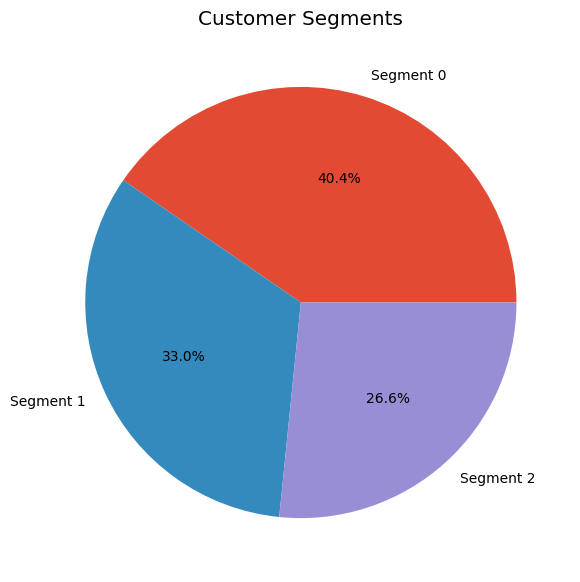

In [ ]:
#Customer Segmentation
segment_counts = (
    customer_metrics['Segment']
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_counts,
    labels=[
        'Segment 0',
        'Segment 1',
        'Segment 2'
    ],
    autopct='%1.1f%%'
)

plt.title("Customer Segments")

plt.show()

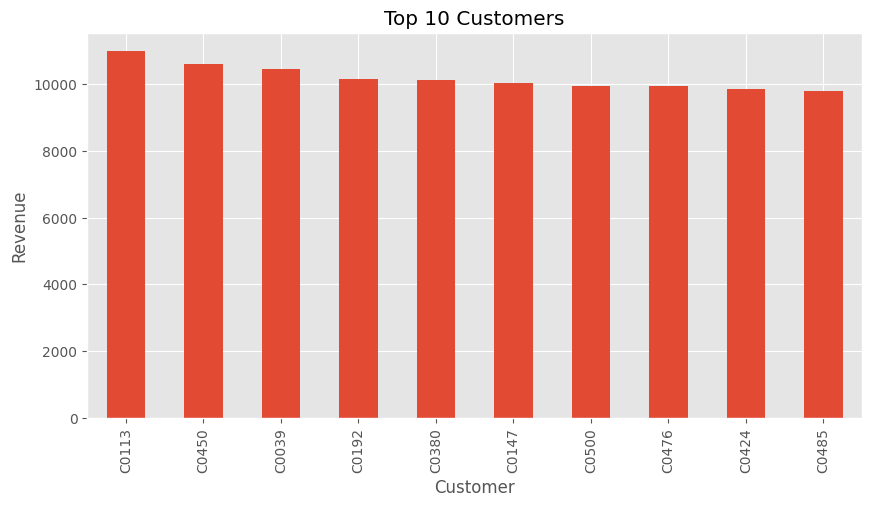

In [ ]:
#Top 10 Customers
top_customers = (
    customer_metrics['TotalRevenue']
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

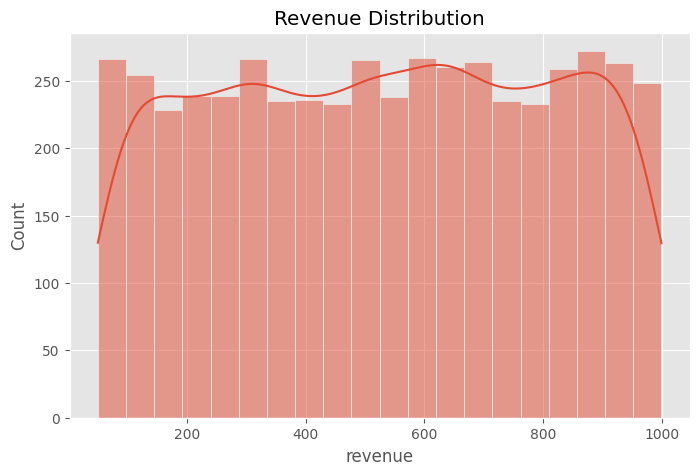

In [ ]:
#Revenue Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['revenue'],
    bins=20,
    kde=True
)

plt.title("Revenue Distribution")

plt.show()

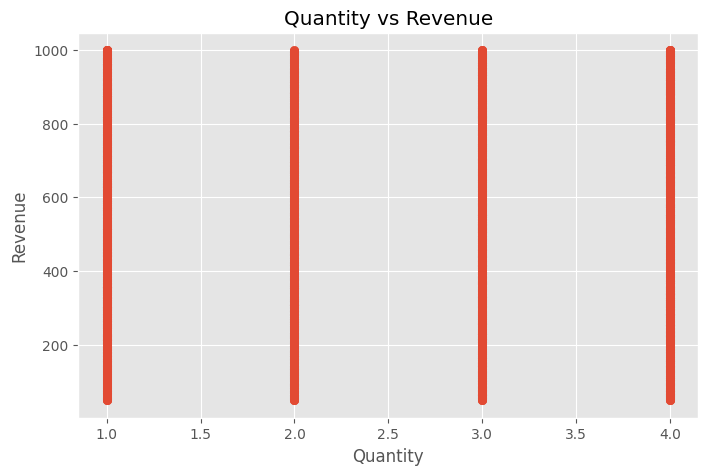

In [ ]:
#Quantity vs Revenue
plt.figure(figsize=(8,5))

plt.scatter(
    df['quantity'],
    df['revenue']
)

plt.title("Quantity vs Revenue")

plt.xlabel("Quantity")

plt.ylabel("Revenue")

plt.show()

In [ ]:
#Business Insights
top_category = (
    df.groupby('category')['revenue']
      .sum()
      .idxmax()
)

top_region = (
    df.groupby('region')['revenue']
      .sum()
      .idxmax()
)

print("\n===== BUSINESS INSIGHTS =====")

print(
    f"Highest Revenue Category: {top_category}"
)

print(
    f"Highest Revenue Region: {top_region}"
)

print(
    "Focus marketing on high-value customers."
)

print(
    "Promote top-performing categories."
)


===== BUSINESS INSIGHTS =====
Highest Revenue Category: Fashion
Highest Revenue Region: South
Focus marketing on high-value customers.
Promote top-performing categories.
